# Task 4b: Shallow Neural Network, Model Comparison and Inference
Uses the modeling table, features and time split from the feature engineering notebook.

| Part | Content |
|---|---|
| 1 | Load the modeling table and the train / validation / test split |
| 2 | Shared helpers: preprocessor, threshold, metrics |
| 3 | Shallow neural network: training loop with class weighting and early stopping |
| 4 | Hyperparameter search on validation, seed stability, learning curves |
| 5 | Save the NN results in the shared format |
| 6 | Comparison of all models on validation, final model choice, one-time test evaluation |
| 7 | Inference function: full record and record with missing values |

## 1. Setup

In [1]:
import os, sys, glob, json, copy, time, warnings, subprocess, importlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, precision_recall_curve, roc_curve)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

try:
    import pyarrow
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "--quiet", "pyarrow"])
    importlib.invalidate_caches()
    import pyarrow

def find_clean_dir():
    if os.path.exists("/kaggle/working/clean/modeling_table.parquet"):
        return "/kaggle/working/clean"
    here = os.path.abspath(os.getcwd())
    for _ in range(4):
        hits = sorted(glob.glob(os.path.join(here, "**", "clean", "modeling_table.parquet"), recursive=True))
        if hits:
            return os.path.dirname(hits[0])
        here = os.path.dirname(here)
    raise FileNotFoundError("clean/modeling_table.parquet not found: run the feature engineering notebook first.")

CLEAN = find_clean_dir()
RESULTS = os.path.join(os.path.dirname(os.path.abspath(CLEAN)), "results")
os.makedirs(RESULTS, exist_ok=True)

cfg = json.load(open(os.path.join(CLEAN, "feature_config.json")))
mdl = pd.read_parquet(os.path.join(CLEAN, "modeling_table.parquet"))
FEATURES, TARGET = cfg["features"], cfg["target"]
BINARY, CONTINUOUS = cfg["binary"], cfg["continuous"]
SEED = cfg.get("seed", 42)

train = mdl[mdl["split"] == "train"].reset_index(drop=True)
val = mdl[mdl["split"] == "val"].reset_index(drop=True)
test = mdl[mdl["split"] == "test"].reset_index(drop=True)
assert train["race_order"].max() < val["race_order"].min() and val["race_order"].max() < test["race_order"].min()

print(f"data: {CLEAN} | results folder: {RESULTS}")
print(f"{len(FEATURES)} features | train {len(train):,} ({train['year'].min()}-{train['year'].max()}) | "
      f"val {len(val):,} ({val['year'].min()}-{val['year'].max()}) | test {len(test):,} ({test['year'].min()}-{test['year'].max()})")
print(f"podium rate: train {train[TARGET].mean():.3f} | val {val[TARGET].mean():.3f} | test {test[TARGET].mean():.3f}")

data: /Users/hanaayman/Documents/GitHub/Formula-1-Podium-Prediction-Companion/clean | results folder: /Users/hanaayman/Documents/GitHub/Formula-1-Podium-Prediction-Companion/results
29 features | train 22,441 (1950-2019) | val 774 (2020-2021) | test 1,351 (2022-2024)
podium rate: train 0.135 | val 0.151 | test 0.151


## 2. Shared helpers
Same preprocessing as the feature engineering notebook (`make_preprocessor("linear")`): median imputation with missing indicators, then scaling; binary flags use the most frequent value. Fitted on training rows only.

The threshold is chosen on validation (maximum F1) and then reused unchanged on test.

In [2]:
def make_preprocessor():
    cont = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
                     ("sc", StandardScaler())])
    return ColumnTransformer([("cont", cont, CONTINUOUS),
                              ("bin", SimpleImputer(strategy="most_frequent", keep_empty_features=True), BINARY)])

def pick_threshold(y, p):
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return float(thr[np.argmax(f1[:-1])])

def all_metrics(d, p, thr):
    y, p = d[TARGET].to_numpy(), np.asarray(p, float)
    yhat = (p >= thr).astype(int)
    top3 = d.assign(_p=p).sort_values(["raceId", "_p"], ascending=[True, False]).groupby("raceId").head(3)
    return dict(roc_auc=roc_auc_score(y, p), pr_auc=average_precision_score(y, p), f1=f1_score(y, yhat),
                precision=precision_score(y, yhat, zero_division=0), recall=recall_score(y, yhat),
                top3_precision=float(top3[TARGET].mean()), threshold=thr)

pre = make_preprocessor().fit(train[FEATURES])
X_tr, X_va, X_te = (pre.transform(d[FEATURES]) for d in (train, val, test))
y_tr, y_va = train[TARGET].to_numpy(), val[TARGET].to_numpy()
print(f"preprocessed: {len(FEATURES)} features -> {X_tr.shape[1]} inputs (incl. missing indicators) | NaN left: {int(np.isnan(X_tr).sum())}")

preprocessed: 29 features -> 43 inputs (incl. missing indicators) | NaN left: 0


## 3. Shallow neural network
- 1 or 2 hidden layers with ReLU, sigmoid output, cross-entropy loss, Adam optimiser.
- **Class imbalance:** podium rows are about 14 %. scikit-learn's MLP has no `class_weight`, so every training epoch uses all non-podium rows plus the podium rows repeated `w ≈ (non-podium / podium)` times. This gives the same loss weighting as `class_weight={0: 1, 1: w}`. Validation and test are never resampled.
- **Regularisation:** L2 penalty (`alpha`) and early stopping.
- **Early stopping:** after each epoch the model is scored on the validation seasons (PR-AUC). Training stops after `patience` epochs without improvement and the best epoch is restored.

In [3]:
POS_WEIGHT = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"podium weight (non-podium / podium): {POS_WEIGHT:.2f}")

def weighted_epoch(X, y, rng):
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    reps = int(np.floor(POS_WEIGHT)); extra = rng.random(len(pos)) < (POS_WEIGHT - reps)
    idx = np.concatenate([neg, np.repeat(pos, reps), pos[extra]])
    rng.shuffle(idx)
    return X[idx], y[idx]

def train_nn(hidden=(64,), alpha=1e-3, lr=1e-3, batch=256, max_epochs=200, patience=15, seed=SEED):
    rng = np.random.default_rng(seed)
    net = MLPClassifier(hidden_layer_sizes=hidden, activation="relu", solver="adam", alpha=alpha,
                        learning_rate_init=lr, batch_size=batch, random_state=seed)
    hist, best, best_score, wait = [], None, -np.inf, 0
    for epoch in range(1, max_epochs + 1):
        Xe, ye = weighted_epoch(X_tr, y_tr, rng)
        net.partial_fit(Xe, ye, classes=[0, 1])
        p_va = net.predict_proba(X_va)[:, 1]
        score = average_precision_score(y_va, p_va)
        hist.append(dict(epoch=epoch, train_loss=net.loss_, val_pr_auc=score,
                         val_roc_auc=roc_auc_score(y_va, p_va)))
        if score > best_score + 1e-4:
            best, best_score, wait = copy.deepcopy(net), score, 0
        else:
            wait += 1
            if wait >= patience:
                break
    return best, pd.DataFrame(hist)

podium weight (non-podium / podium): 6.43


## 4. Hyperparameter search (validation only)
Six settings: network size (one or two layers) and L2 strength. Each is trained with the early-stopping loop above and ranked by validation PR-AUC. The test seasons are not used.

In [4]:
GRID = [dict(hidden=(32,), alpha=1e-3), dict(hidden=(64,), alpha=1e-3), dict(hidden=(64,), alpha=1e-2),
        dict(hidden=(64, 32), alpha=1e-3), dict(hidden=(64, 32), alpha=1e-2), dict(hidden=(128, 64), alpha=1e-2)]
rows, runs = [], {}
for g in GRID:
    t0 = time.time()
    net, hist = train_nn(**g)
    p = net.predict_proba(X_va)[:, 1]
    key = f"{g['hidden']} alpha={g['alpha']}"
    runs[key] = (net, hist, g)
    rows.append(dict(setting=key, best_epoch=int(hist["val_pr_auc"].idxmax()) + 1, epochs_run=len(hist),
                     val_pr_auc=average_precision_score(y_va, p), val_roc_auc=roc_auc_score(y_va, p),
                     seconds=round(time.time() - t0, 1)))
search = pd.DataFrame(rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
display(search.round(4))
BEST_KEY = search.loc[0, "setting"]; BEST_CFG = runs[BEST_KEY][2]
print("best setting:", BEST_KEY)

,setting,best_epoch,epochs_run,val_pr_auc,val_roc_auc,seconds
0,"(64, 32) alpha=0.01",8,23,0.7479,0.9275,1.7
1,"(64, 32) alpha=0.001",9,24,0.7474,0.9264,1.6
2,"(64,) alpha=0.01",8,23,0.7444,0.9288,1.2
3,"(64,) alpha=0.001",4,19,0.7388,0.9317,1.0
4,"(32,) alpha=0.001",17,32,0.7332,0.9299,1.6
5,"(128, 64) alpha=0.01",1,16,0.7304,0.9321,2.2


best setting: (64, 32) alpha=0.01


### 4.1 Seed stability
A neural network depends on its random start. The best setting is retrained with three seeds; the spread shows how much of a difference between models is just noise.

In [5]:
seed_rows, seed_models = [], {}
for s in [SEED, SEED + 1, SEED + 2]:
    net, hist = train_nn(**BEST_CFG, seed=s)
    p = net.predict_proba(X_va)[:, 1]
    seed_models[s] = (net, hist)
    seed_rows.append(dict(seed=s, val_pr_auc=average_precision_score(y_va, p), val_roc_auc=roc_auc_score(y_va, p),
                          best_epoch=int(hist["val_pr_auc"].idxmax()) + 1))
seeds = pd.DataFrame(seed_rows); display(seeds.round(4))
print(f"val PR-AUC {seeds['val_pr_auc'].mean():.4f} ± {seeds['val_pr_auc'].std():.4f} | "
      f"val ROC-AUC {seeds['val_roc_auc'].mean():.4f} ± {seeds['val_roc_auc'].std():.4f}")
nn_net, nn_hist = seed_models[SEED]          # the reported model: first seed (fixed in advance, not cherry-picked)

,seed,val_pr_auc,val_roc_auc,best_epoch
0,42,0.7479,0.9275,8
1,43,0.7363,0.9255,9
2,44,0.7340,0.9303,3


val PR-AUC 0.7394 ± 0.0074 | val ROC-AUC 0.9278 ± 0.0024


### 4.2 Learning curves

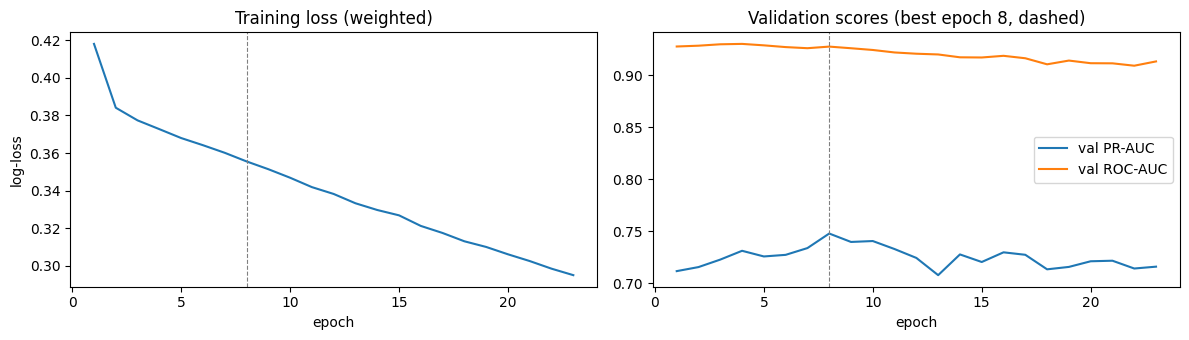

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(nn_hist["epoch"], nn_hist["train_loss"]); axes[0].set(title="Training loss (weighted)", xlabel="epoch", ylabel="log-loss")
axes[1].plot(nn_hist["epoch"], nn_hist["val_pr_auc"], label="val PR-AUC")
axes[1].plot(nn_hist["epoch"], nn_hist["val_roc_auc"], label="val ROC-AUC")
best_ep = int(nn_hist["val_pr_auc"].idxmax()) + 1
for ax in axes: ax.axvline(best_ep, color="grey", ls="--", lw=0.8)
axes[1].set(title=f"Validation scores (best epoch {best_ep}, dashed)", xlabel="epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Save the NN in the shared format
Every model (also the teammate's logistic regression, random forest and gradient boosting) saves three files in `results/`:
- `<name>.json`: model name, settings, validation threshold and validation metrics
- `<name>_preds.parquet`: `resultId, raceId, split, podium, p` for validation **and** test rows
- `<name>_model.joblib`: the fitted pipeline (preprocessor + model), with `predict_proba`

The comparison in Part 6 reads every model saved this way.

In [7]:
nn_model = Pipeline([("pre", pre), ("clf", nn_net)])          # already fitted: preprocessor on train, network above
p_va = nn_model.predict_proba(val[FEATURES])[:, 1]
nn_thr = pick_threshold(y_va, p_va)
nn_val = all_metrics(val, p_va, nn_thr)

def save_model(name, label, model, params, thr, val_metrics):
    preds = pd.concat([d[["resultId", "raceId", "split", TARGET]].assign(p=model.predict_proba(d[FEATURES])[:, 1])
                       for d in (val, test)])
    preds.to_parquet(os.path.join(RESULTS, f"{name}_preds.parquet"), index=False)
    joblib.dump(model, os.path.join(RESULTS, f"{name}_model.joblib"))
    json.dump(dict(model=label, params=params, threshold=thr, val=val_metrics),
              open(os.path.join(RESULTS, f"{name}.json"), "w"), indent=2, default=float)

save_model("nn", "Shallow NN", nn_model, dict(hidden=list(BEST_CFG["hidden"]), alpha=BEST_CFG["alpha"],
           lr=1e-3, epochs=best_ep, seed=SEED, seed_pr_auc_std=float(seeds["val_pr_auc"].std())), nn_thr, nn_val)
print({k: round(v, 4) for k, v in nn_val.items()})

{'roc_auc': np.float64(0.9275), 'pr_auc': np.float64(0.7479), 'f1': 0.7177, 'precision': 0.6794, 'recall': 0.7607, 'top3_precision': 0.7094, 'threshold': 0.7384}


## 6. Comparison of all models
Two reference points are added:
- **No skill:** a model that ranks randomly; its PR-AUC equals the podium rate.
- **Grid rule:** predict a podium when the starting slot is 1-3; the score is `-grid`. Every real model should beat it.

The final model is chosen on **validation PR-AUC**. If two models are within 0.01, the simpler one is preferred. The test seasons are scored only after the choice, once, with each model's validation threshold.

In [8]:
models = {}
for f in sorted(glob.glob(os.path.join(RESULTS, "*.json"))):
    name = os.path.basename(f)[:-5]
    if os.path.exists(os.path.join(RESULTS, f"{name}_preds.parquet")):
        models[name] = dict(meta=json.load(open(f)), preds=pd.read_parquet(os.path.join(RESULTS, f"{name}_preds.parquet")))
print("models found:", {k: v["meta"]["model"] for k, v in models.items()})
if len(models) == 1:
    print("Only the NN is saved so far: run the teammate's notebook (LR / RF / boosting) first, then re-run this part.")

def preds_for(name, d):
    pr = models[name]["preds"].set_index("resultId")["p"]
    return pr.reindex(d["resultId"]).to_numpy()

grid_score = lambda d: -d["grid_clean"].to_numpy()
grid_thr = -3.0                                     # rule: grid 1-3 -> podium

rows = [dict(model="Grid rule (grid <= 3)", **all_metrics(val, grid_score(val), grid_thr))]
for name, m in models.items():
    rows.append(dict(model=m["meta"]["model"], **all_metrics(val, preds_for(name, val), m["meta"]["threshold"])))
cmp_val = pd.DataFrame(rows).set_index("model").sort_values("pr_auc", ascending=False)
print(f"no-skill PR-AUC on validation = podium rate = {val[TARGET].mean():.3f}")
display(cmp_val.round(4))

models found: {'nn': 'Shallow NN'}
Only the NN is saved so far: run the teammate's notebook (LR / RF / boosting) first, then re-run this part.
no-skill PR-AUC on validation = podium rate = 0.151


,roc_auc,pr_auc,f1,precision,recall,top3_precision,threshold
model,,,,,,,
Shallow NN,0.9275,0.7479,0.7177,0.6794,0.7607,0.7094,0.7384
Grid rule (grid <= 3),0.9101,0.6478,0.6953,0.6983,0.6923,0.7009,-3.0000


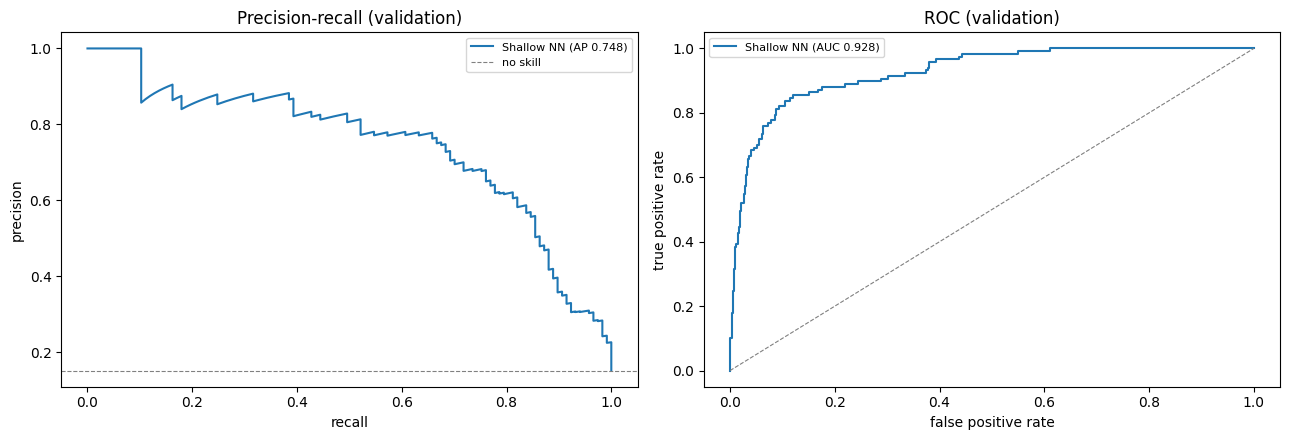

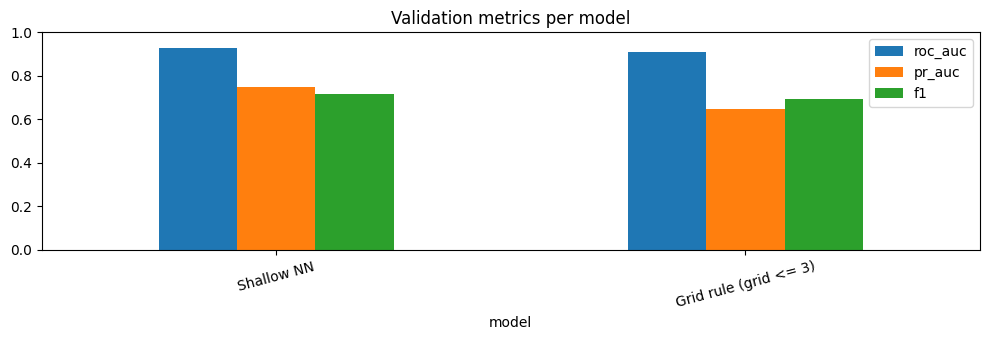

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, m in models.items():
    p = preds_for(name, val)
    pr, rc, _ = precision_recall_curve(y_va, p); fpr, tpr, _ = roc_curve(y_va, p)
    lab = m["meta"]["model"]
    axes[0].plot(rc, pr, label=f"{lab} (AP {average_precision_score(y_va, p):.3f})")
    axes[1].plot(fpr, tpr, label=f"{lab} (AUC {roc_auc_score(y_va, p):.3f})")
axes[0].axhline(val[TARGET].mean(), color="grey", ls="--", lw=0.8, label="no skill")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=0.8)
axes[0].set(title="Precision-recall (validation)", xlabel="recall", ylabel="precision"); axes[0].legend(fontsize=8)
axes[1].set(title="ROC (validation)", xlabel="false positive rate", ylabel="true positive rate"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

cmp_val[["roc_auc", "pr_auc", "f1"]].plot(kind="bar", figsize=(10, 3.5), rot=15, title="Validation metrics per model")
plt.ylim(0, 1); plt.tight_layout(); plt.show()

### 6.1 Final model choice and one-time test evaluation

In [10]:
COMPLEXITY = {"logreg": 0, "lr": 0, "rf": 1, "hgb": 1, "xgb": 1, "lgbm": 1, "nn": 2}   # lower = simpler
val_rank = pd.DataFrame([dict(name=n, label=m["meta"]["model"],
                              pr_auc=all_metrics(val, preds_for(n, val), m["meta"]["threshold"])["pr_auc"])
                         for n, m in models.items()])
top = val_rank["pr_auc"].max()
near = val_rank[val_rank["pr_auc"] >= top - 0.01].copy()
near["complexity"] = near["name"].map(lambda n: COMPLEXITY.get(n, 1))
FINAL = near.sort_values(["complexity", "pr_auc"], ascending=[True, False]).iloc[0]["name"]
print(f"final model: {models[FINAL]['meta']['model']} (best validation PR-AUC {top:.4f}; "
      f"models within 0.01: {near['label'].tolist()})")

# ---- the test seasons are scored here, once, with thresholds fixed on validation ----
rows = [dict(model="Grid rule (grid <= 3)", split="val", **all_metrics(val, grid_score(val), grid_thr)),
        dict(model="Grid rule (grid <= 3)", split="test", **all_metrics(test, grid_score(test), grid_thr))]
for name, m in models.items():
    for split, d in (("val", val), ("test", test)):
        rows.append(dict(model=m["meta"]["model"], split=split, **all_metrics(d, preds_for(name, d), m["meta"]["threshold"])))
final_table = pd.DataFrame(rows).pivot(index="model", columns="split",
                                       values=["roc_auc", "pr_auc", "f1", "precision", "recall", "top3_precision"])
display(final_table.round(3))
print(f"no-skill PR-AUC: val {val[TARGET].mean():.3f} | test {test[TARGET].mean():.3f}")

final_model = joblib.load(os.path.join(RESULTS, f"{FINAL}_model.joblib"))
final_threshold = float(models[FINAL]["meta"]["threshold"])
json.dump(dict(final_model=FINAL, label=models[FINAL]["meta"]["model"], threshold=final_threshold),
          open(os.path.join(RESULTS, "final_model.json"), "w"), indent=2)
print("saved results/final_model.json for the ablation and XAI sections")

final model: Shallow NN (best validation PR-AUC 0.7479; models within 0.01: ['Shallow NN'])


roc_auc        pr_auc            f1        precision  \
split                    test    val   test    val   test    val      test   
model                                                                        
Grid rule (grid <= 3)   0.913  0.910  0.647  0.648  0.649  0.695     0.650   
Shallow NN              0.918  0.928  0.689  0.748  0.644  0.718     0.599   

                             recall        top3_precision         
split                    val   test    val           test    val  
model                                                             
Grid rule (grid <= 3)  0.698  0.647  0.692          0.652  0.701  
Shallow NN             0.679  0.696  0.761          0.647  0.709

no-skill PR-AUC: val 0.151 | test 0.151
saved results/final_model.json for the ablation and XAI sections


## 7. Inference function
`predict_podium(...)` takes the pre-race facts of one driver in one race and returns the podium probability of the final model.

It reuses `build_modeling_table` from the feature engineering notebook (copied below unchanged): the new entry is added to the clean tables and the features are rebuilt, so form, standings and circuit history come from earlier races exactly as in training. The entry's outcome is unknown, so a placeholder is stored; the leakage test in feature engineering showed that a row's own outcome never changes its own features.

In [11]:
FORM_WINDOWS = [3, 5, 10]
FAMILIES = ["drv_podium_rate", "drv_finish_rel", "team_podium_rate", "team_finish_rel"]   # core form (finishing positions)
STATUS_FAMILIES = ["drv_dnf_rate", "team_dnf_rate"]                                        # status-derived: candidate only
ALL_FAMILIES = FAMILIES + STATUS_FAMILIES
ID_COLS = ["resultId", "raceId", "driverId", "constructorId", "circuitId", "year", "round", "race_order"]
TARGET = "podium"
BINARY_FEATURES = ["pole", "pit_lane_start", "front_row", "home_race"]

def _roll_past(df, keys, col, w):
    # mean of the PREVIOUS w values within each group: shift(1) removes the current row.
    # Needs `df` sorted chronologically (it is: sorted by race_order).
    return df.groupby(keys)[col].transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())

def build_modeling_table(tbls, windows=FORM_WINDOWS):
    # ---- calendar: a strict chronological order of races (year, round) ----------------------
    races = tbls["races"][["raceId", "year", "round", "circuitId", "date"]].copy()
    races = races.sort_values(["year", "round"]).reset_index(drop=True)
    races["race_order"] = np.arange(len(races))
    for c in ["raceId", "year", "round", "circuitId"]:
        races[c] = races[c].astype("int64")
    races["n_rounds"] = races.groupby("year")["round"].transform("max")

    r = tbls["results"][["resultId", "raceId", "driverId", "constructorId", "grid",
                         "positionOrder", "statusId"]].copy()
    for c in ["resultId", "raceId", "driverId", "constructorId", "grid", "positionOrder", "statusId"]:
        r[c] = r[c].astype("int64")
    stt = tbls["status"][["statusId", "status"]].copy(); stt["statusId"] = stt["statusId"].astype("int64")
    r["status_name"] = r["statusId"].map(stt.set_index("statusId")["status"]).fillna("")
    circ = tbls["circuits"][["circuitId", "country"]].rename(columns={"country": "circuit_country"}).copy()
    circ["circuitId"] = circ["circuitId"].astype("int64")
    drv = tbls["drivers"][["driverId", "dob", "nationality"]].copy()
    drv["driverId"] = drv["driverId"].astype("int64")

    df = (r.merge(races, on="raceId", how="left", validate="m:1")
           .merge(circ, on="circuitId", how="left", validate="m:1")
           .merge(drv, on="driverId", how="left", validate="m:1"))
    df = df.sort_values(["race_order", "driverId"]).reset_index(drop=True)

    # ---- target and the outcome helpers (outcomes are only ever used through shift) ------------
    df[TARGET] = (df["positionOrder"] <= 3).astype(int)
    df["field_size"] = df.groupby("raceId")["driverId"].transform("size").astype(float)
    df["_podium"] = df[TARGET].astype(float)
    df["_finish_rel"] = df["positionOrder"] / df["field_size"]     # era-independent finishing position
    # retirement = the car stopped: status other than "Finished" / "+n Laps" / "Lapped" (reference document), DSQ excluded.
    # NOT positionText == "R": a driver who retired after 90% of the distance is classified and has a numeric position.
    _fin = df["status_name"].isin(["Finished", "Lapped"]) | df["status_name"].str.startswith("+")
    df["_dnf"] = (~_fin & (df["status_name"] != "Disqualified")).astype(float)

    # ---- GRID group (known when the grid is set) -----------------------------------------------
    max_grid = df.groupby("raceId")["grid"].transform("max")
    back = max_grid + 1
    df["pit_lane_start"] = (df["grid"] == 0).astype(float)
    df["grid_clean"] = np.where(df["grid"] > 0, df["grid"], np.where(max_grid > 0, back, np.nan)).astype(float)
    df["grid_rel"] = df["grid_clean"] / df["field_size"]
    df["front_row"] = (df["grid_clean"] <= 2).astype(float).where(df["grid_clean"].notna())
    df["pole"] = (df["grid_clean"] == 1).astype(float).where(df["grid_clean"].notna())
    gt = df.groupby(["raceId", "constructorId"])["grid_clean"]
    df["team_best_grid"] = gt.transform("min")
    df["grid_vs_team"] = df["grid_clean"] - gt.transform("mean")

    # ---- QUALIFYING group ----------------------------------------------------------------------
    q = tbls["qualifying"][["raceId", "driverId", "position", "q1", "q2", "q3"]].copy()
    q["raceId"] = q["raceId"].astype("int64"); q["driverId"] = q["driverId"].astype("int64")
    q["quali_pos"] = q["position"].astype(float)
    for c in ["q1", "q2", "q3"]:
        q[c] = q[c].astype(float)
        q[f"_gap_{c}"] = 100 * (q[c] / q.groupby("raceId")[c].transform("min") - 1)   # % slower than the session's fastest
    q["q1_gap_pct"] = q["_gap_q1"]
    # gap in the LAST session the driver reached (Q3 -> Q2 -> Q1): comparable across the single-lap (2003-05) and knockout (2006+) formats
    q["quali_gap_pct"] = q["_gap_q3"].fillna(q["_gap_q2"]).fillna(q["_gap_q1"])
    df = df.merge(q[["raceId", "driverId", "quali_pos", "q1_gap_pct", "quali_gap_pct"]],
                  on=["raceId", "driverId"], how="left", validate="1:1")
    df["quali_pos_rel"] = df["quali_pos"] / df["field_size"]
    df["grid_minus_quali"] = np.where((df["grid"] > 0) & df["quali_pos"].notna(), df["grid"] - df["quali_pos"], np.nan)

    # ---- FORM group: only previous races ---------------------------------------------------------
    drv_src = {"drv_podium_rate": "_podium", "drv_finish_rel": "_finish_rel", "drv_dnf_rate": "_dnf"}
    team_src = {"team_podium_rate": "_podium", "team_finish_rel": "_finish_rel", "team_dnf_rate": "_dnf"}
    for fam, col in drv_src.items():
        for w in windows:
            df[f"{fam}_w{w}"] = _roll_past(df, "driverId", col, w)
    team = (df.groupby(["constructorId", "raceId", "race_order"], as_index=False)[["_podium", "_finish_rel", "_dnf"]].mean()
              .sort_values(["constructorId", "race_order"]).reset_index(drop=True))
    tcols = []
    for fam, col in team_src.items():
        for w in windows:
            team[f"{fam}_w{w}"] = _roll_past(team, "constructorId", col, w); tcols.append(f"{fam}_w{w}")
    df = df.merge(team[["constructorId", "raceId"] + tcols], on=["constructorId", "raceId"], how="left", validate="m:1")
    g = df.groupby("driverId")
    df["drv_career_starts"] = g.cumcount().astype(float)
    prev_pod = g["_podium"].cumsum() - df["_podium"]
    df["drv_career_podium_rate"] = prev_pod / df["drv_career_starts"].replace(0, np.nan)

    # ---- STANDINGS group: championship table after the previous round of the same season ---------
    def prior_standing(kind, ent, prefix):
        st = tbls[f"{kind}_standings"][["raceId", ent, "position", "points", "wins"]].copy()
        st = st.merge(races[["raceId", "year", "round"]], on="raceId", how="inner")
        for c in ["raceId", ent]: st[c] = st[c].astype("int64")
        lead = st.groupby("raceId")["points"].transform("max").astype(float)
        st[f"{prefix}_pts_share_prev"] = np.where(lead > 0, st["points"].astype(float) / lead, 0.0)
        st[f"{prefix}_champ_pos_prev"] = st["position"].astype(float)
        st[f"{prefix}_wins_prev"] = st["wins"].astype(float)
        cols = [f"{prefix}_champ_pos_prev", f"{prefix}_pts_share_prev", f"{prefix}_wins_prev"]
        st = st.sort_values("round")
        left = df[["resultId", ent, "year", "round"]].sort_values("round")
        # allow_exact_matches=False => strictly EARLIER rounds: the standing after this race is never used
        m = pd.merge_asof(left, st[[ent, "year", "round"] + cols], on="round", by=[ent, "year"],
                          allow_exact_matches=False, direction="backward")
        has_table = m["year"].isin(set(st["year"]))
        for c in cols[1:]:                       # nothing scored yet this season => 0 (position stays NaN)
            m.loc[has_table & m[c].isna(), c] = 0.0
        return m[["resultId"] + cols]
    df = df.merge(prior_standing("driver", "driverId", "drv"), on="resultId", how="left", validate="1:1")
    df = df.merge(prior_standing("constructor", "constructorId", "con"), on="resultId", how="left", validate="1:1")

    # ---- CIRCUIT HISTORY group: previous races only ----------------------------------------------
    gdc = df.groupby(["driverId", "circuitId"])
    df["drv_circuit_prev_starts"] = gdc.cumcount().astype(float)
    df["drv_circuit_prev_podiums"] = gdc["_podium"].cumsum() - df["_podium"]
    df["_front"] = (df["grid_clean"] <= 2).astype(float)
    df["_front_pod"] = df["_front"] * df["_podium"]
    cr = (df.groupby(["circuitId", "raceId", "race_order"], as_index=False)[["_front", "_front_pod"]].sum()
            .sort_values(["circuitId", "race_order"]).reset_index(drop=True))
    for c in ["_front", "_front_pod"]:     # only the last 8 races at the circuit: early-era reliability was far lower (reference document)
        cr["past" + c] = cr.groupby("circuitId")[c].transform(lambda s: s.shift(1).rolling(8, min_periods=3).sum())
    cr["circuit_front_row_podium_rate"] = np.where(cr["past_front"] >= 6, cr["past_front_pod"] / cr["past_front"], np.nan)
    df = df.merge(cr[["circuitId", "raceId", "circuit_front_row_podium_rate"]],
                  on=["circuitId", "raceId"], how="left", validate="m:1")

    # ---- CONTEXT group ---------------------------------------------------------------------------
    df["season_progress"] = df["round"] / df["n_rounds"]
    df["age"] = (df["date"] - df["dob"]).dt.days / 365.25
    nm = tbls["nationality_country"][["nationality", "country"]].drop_duplicates().assign(home_race=1.0)
    df = df.merge(nm, left_on=["nationality", "circuit_country"], right_on=["nationality", "country"],
                  how="left", validate="m:1").drop(columns="country")
    df["home_race"] = df["home_race"].fillna(0.0)

    groups = {
        "grid": ["grid_clean", "grid_rel", "pole", "pit_lane_start", "front_row", "team_best_grid", "grid_vs_team"],
        "qualifying": ["quali_pos", "quali_pos_rel", "quali_gap_pct", "q1_gap_pct", "grid_minus_quali"],
        "driver_form": [f"{fam}_w{w}" for fam in ["drv_podium_rate", "drv_finish_rel"] for w in windows]
                       + ["drv_career_starts", "drv_career_podium_rate"],
        "constructor_form": [f"{fam}_w{w}" for fam in ["team_podium_rate", "team_finish_rel"] for w in windows],
        "reliability_status": [f"{fam}_w{w}" for fam in STATUS_FAMILIES for w in windows],
        "standings": ["drv_champ_pos_prev", "drv_pts_share_prev", "drv_wins_prev",
                      "con_champ_pos_prev", "con_pts_share_prev", "con_wins_prev"],
        "circuit_history": ["drv_circuit_prev_starts", "drv_circuit_prev_podiums", "circuit_front_row_podium_rate"],
        "context": ["field_size", "season_progress", "age", "home_race"],
    }
    feats = [f for fs in groups.values() for f in fs]
    out = df[ID_COLS + [TARGET] + feats].copy()
    out[feats] = out[feats].astype(float)
    return out.reset_index(drop=True), groups

In [12]:
names = ["circuits","constructors","constructor_results","constructor_standings","drivers","driver_standings","races",
         "results","qualifying","lap_times","pit_stops","sprint_results","seasons","status","nationality_country"]
tables = {n: pd.read_parquet(os.path.join(CLEAN, f"{n}.parquet")) for n in names}

def predict_podium(raceId, driverId, constructorId, grid, quali_pos=None, q1=None, q2=None, q3=None,
                   model=None, threshold=None):
    model = final_model if model is None else model
    threshold = final_threshold if threshold is None else threshold
    t = dict(tables)
    res = t["results"]
    # the entry being predicted replaces any stored row of this driver in this race
    res = res[~((res["raceId"].astype(int) == raceId) & (res["driverId"].astype(int) == driverId))]
    new_id = int(t["results"]["resultId"].max()) + 1
    finished = int(t["status"].loc[t["status"]["status"] == "Finished", "statusId"].iloc[0])
    row = pd.DataFrame([dict(resultId=new_id, raceId=raceId, driverId=driverId, constructorId=constructorId,
                             grid=grid, positionOrder=99, statusId=finished)])     # placeholder outcome
    t["results"] = pd.concat([res, row.astype({c: res[c].dtype for c in row.columns if c in res})], ignore_index=True)
    q = t["qualifying"]
    q = q[~((q["raceId"].astype(int) == raceId) & (q["driverId"].astype(int) == driverId))]
    if quali_pos is not None:
        q = pd.concat([q, pd.DataFrame([dict(raceId=raceId, driverId=driverId, position=quali_pos,
                                             q1=q1, q2=q2, q3=q3)])], ignore_index=True)
    t["qualifying"] = q
    feats, _ = build_modeling_table(t)
    x = feats.loc[feats["resultId"] == new_id, FEATURES]
    p = float(model.predict_proba(x)[:, 1][0])
    return dict(podium_probability=round(p, 3), predicted_podium=bool(p >= threshold), threshold=round(threshold, 3),
                missing_features=[f for f in FEATURES if x[f].isna().iloc[0]])

### 7.1 Demonstration
A real race from the test seasons: the last race in the data. The inputs are the pre-race facts (grid and qualifying); the real result is shown next to the prediction only for comparison.

In [13]:
r = tables["results"].astype({"raceId": int, "driverId": int})
demo_race = int(test.sort_values("race_order")["raceId"].iloc[-1])
race_info = tables["races"].loc[tables["races"]["raceId"].astype(int) == demo_race, ["year", "round", "name"]].iloc[0]
q_all = tables["qualifying"].astype({"raceId": int, "driverId": int})
drivers = tables["drivers"].assign(driverId=lambda d: d["driverId"].astype(int)).set_index("driverId")
entries = r[r["raceId"] == demo_race].sort_values("grid").head(6)
print(f"Race: {race_info['year']} round {race_info['round']} - {race_info['name']}")

rows = []
for e in entries.itertuples():
    qq = q_all[(q_all["raceId"] == demo_race) & (q_all["driverId"] == e.driverId)]
    qd = qq.iloc[0] if len(qq) else None
    out = predict_podium(demo_race, int(e.driverId), int(e.constructorId), int(e.grid),
                         quali_pos=None if qd is None else int(qd["position"]),
                         q1=None if qd is None else qd["q1"], q2=None if qd is None else qd["q2"], q3=None if qd is None else qd["q3"])
    rows.append(dict(driver=f"{drivers.loc[e.driverId, 'forename']} {drivers.loc[e.driverId, 'surname']}", grid=int(e.grid),
                     **{k: v for k, v in out.items() if k != "missing_features"}, actual_finish=int(e.positionOrder)))
print("1) Full records (grid + qualifying known):")
display(pd.DataFrame(rows))

Race: 2024 round 24 - Abu Dhabi Grand Prix
1) Full records (grid + qualifying known):


,driver,grid,podium_probability,predicted_podium,threshold,actual_finish
0,Lando Norris,1,0.952,True,0.738,1
1,Oscar Piastri,2,0.924,True,0.738,10
2,Carlos Sainz,3,0.784,True,0.738,2
3,Max Verstappen,4,0.937,True,0.738,6
4,Pierre Gasly,5,0.141,False,0.738,7
5,George Russell,6,0.602,False,0.738,5


In [14]:
e = entries.iloc[0]
qd = q_all[(q_all["raceId"] == demo_race) & (q_all["driverId"] == int(e["driverId"]))].iloc[0]
args = (demo_race, int(e["driverId"]), int(e["constructorId"]), int(e["grid"]))
full = predict_podium(*args, quali_pos=int(qd["position"]), q1=qd["q1"], q2=qd["q2"], q3=qd["q3"])
no_quali = predict_podium(*args)                                                         # qualifying unknown
debut = predict_podium(demo_race, int(drivers.index.max()) + 1, int(e["constructorId"]), 10)   # unknown driver, no history

show = lambda d: {k: v for k, v in d.items() if k != "missing_features"}
print("2) Full record (grid + qualifying)         :", show(full))
print("3) Same driver, qualifying MISSING         :", show(no_quali))
print("   missing features:", no_quali["missing_features"])
print("4) New driver (no history), grid 10        :", show(debut))
print("   missing features:", debut["missing_features"])

2) Full record (grid + qualifying)         : {'podium_probability': 0.952, 'predicted_podium': True, 'threshold': 0.738}
3) Same driver, qualifying MISSING         : {'podium_probability': 0.934, 'predicted_podium': True, 'threshold': 0.738}
   missing features: ['quali_pos', 'quali_gap_pct', 'q1_gap_pct', 'grid_minus_quali']
4) New driver (no history), grid 10        : {'podium_probability': 0.295, 'predicted_podium': False, 'threshold': 0.738}
   missing features: ['quali_pos', 'quali_gap_pct', 'q1_gap_pct', 'grid_minus_quali', 'drv_podium_rate_w10', 'drv_finish_rel_w10', 'drv_career_podium_rate', 'drv_champ_pos_prev', 'age']


### Summary
- Shallow NN: best setting, epochs and validation scores are in Part 4; seed spread in 4.1.
- Comparison: validation table and curves in Part 6; final model chosen on validation PR-AUC; test scored once (6.1).
- Saved for Tasks 5-6: `results/final_model.json` and every model's `results/<name>_model.joblib`.
- Inference: `predict_podium(...)` works with full records and with missing qualifying data or no driver history; missing values are filled by the training-fitted preprocessor and flagged by the missing indicators.